# Resnet Size
It expeccts 224 x 224

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data.sampler import SubsetRandomSampler
import torch.optim
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')

import torchvision as tv
from torchvision import datasets
import torchvision.transforms as T
import torchvision.models

import random
import multiprocessing
import numpy as np
import pandas as pd
import seaborn as sns
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

### Transformations
- Resizing to be 256 x 256
- Making them the correct size before ResNet50
- Random + horizontal flips, convert to pytorch tensors, normalize the values 
- ToTensor converts to a pytorch tensor and divides everything by 255
- The next one is going to normalize it again and situate the data between -1 and 1
- Same thing for validation set and the test set

In [ ]:
def get_transforms(rand_augment_magnitude):

    # These are the per-channel mean and std of CIFAR-10 over the dataset
    mean = (0.49139968, 0.48215827, 0.44653124)
    std = (0.24703233, 0.24348505, 0.26158768)

    # Define our transformations
    return {"train": T.Compose([
                T.Resize(256), # All images in CIFAR-10 are 32x32. We enlarge them a bit so we can then take a random crop
                T.RandomCrop(224), # take a random part of the image
                T.RandomHorizontalFlip(0.5),
                T.RandAugment(num_ops=2, magnitude=rand_augment_magnitude, interpolation=T.InterpolationMode.BILINEAR,),
                T.ToTensor(),
                T.Normalize(mean, std),]),
            "valid": T.Compose([
                T.Resize(256),
                T.CenterCrop(224),
                T.ToTensor(),
                T.Normalize(mean, std),]),
            "test": T.Compose([
                T.Resize(256),
                T.CenterCrop(224),
                T.ToTensor(),
                T.Normalize(mean, std),]),}

In [ ]:
def get_data_loaders(batch_size, valid_size, transforms, num_workers, random_seed=1971):

    # Reseed random number generators to get a deterministic split. This is useful when comparing experiments, so you'll know they all run on the same data.
    # In principle you should repeat this a few times (cross validation) to see the variability of your measurements.
    torch.manual_seed(random_seed)
    random.seed(random_seed)
    np.random.seed(random_seed)

    # Get the CIFAR10 training dataset from torchvision.datasets and set the transforms.
    # We will split this further into train and validation in this function.
    train_data = datasets.CIFAR10("data", train=True, download=True, transform=transforms['train'])
    valid_data = datasets.CIFAR10("data", train=True, download=True, transform=transforms['valid'])

    # Compute how many items we will reserve for the validation set
    n_tot = len(train_data)
    split = int(np.floor(valid_size * n_tot))

    # compute the indices for the training set and for the validation set
    shuffled_indices = torch.randperm(n_tot)
    train_idx, valid_idx = shuffled_indices[split:], shuffled_indices[:split]

    # define samplers for obtaining training and validation batches
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    # prepare data loaders (combine dataset and sampler)
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
    valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)

    # Get the CIFAR10 test dataset from torchvision.datasets, set the transforms, and prepare the data loader.

    test_data = datasets.CIFAR10("data", train=False, download=True, transform=transforms['test'])
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, num_workers=num_workers)

    return {'train': train_loader, 'valid': valid_loader, 'test': test_loader}

In [ ]:
n_workers = multiprocessing.cpu_count() # number of logical CPUs
print('Using {} logical CPUs.'.format(n_workers))

batch_size = 32 # training batch size
valid_size = 0.2 # proportion of downloaded training data to use for validation

transforms = get_transforms(rand_augment_magnitude=2)
data_loaders = get_data_loaders(batch_size, valid_size, transforms, n_workers)

Using 12 logical CPUs.


/home/rwh/anaconda3/envs/py314_pt210/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [ ]:
# specify the image class labels
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"]

### Create the Model
Now we will load the pretrained ResNet model and substitue the head of the model (_the part near the output_) with a fully-connected layer having the correct input and output dimenstions.

In [ ]:
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)

n_classes = len(classes)
n_inputs = model.fc.in_features

# Feel free to experiment with more complicated heads
model.fc = nn.Linear(n_inputs, n_classes)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/rwh/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:04<00:00, 23.2MB/s]


### Adjusting the Trainability of Parameters
Now we want to make it so that the parameters of the model's _backbone_ are not trainable; this is called **freezing the backbone**. We also want to ensure that the fully connected layer that we just added has trainable parameters; this is called **thawing the head**.

In [ ]:
frozen_parameters = []

for p in model.parameters():
    # Freeze only parameters that are not already frozen
    if p.requires_grad:
        p.requires_grad = False
        frozen_parameters.append(p)

print(f"Froze {len(frozen_parameters)} groups of parameters")

# Now let's thaw the parameters of the head we have added
for p in model.fc.parameters():
    p.requires_grad = True

Froze 161 groups of parameters


In [ ]:
# Print the model if you want to see what it looks like.
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### How Many Trainable Parameters?
Run the cell below to see how many trainable parameters there are.

In [ ]:
# Run this cell to see how many trainable parameters there are.

sum(p.numel() for p in model.parameters() if p.requires_grad)

20490

### Visualize the model using the [Neutron App](https://netron.app/)

In [ ]:
# Run this cell to create the model viewer file,
# then upload the file to the neutron.app website.

scripted = torch.jit.script(model)
torch.jit.save(scripted, "ResNet_Transfer.pt")

### Define Loss Function and Optimizer
In the cell below, we'll tell PyTorch what loss function and optimizer to use. Since this problem is a multi-class classification problem, we should use _Categorical Cross Entropy_ for the loss function.

For the optimizer, either _SGD_ or _Adam_ will be fine. The first argument tells the optimizer what to optimize; the second argument tells the optimizer what the learning rate is.

Obviously, different optimizers will have different hyperparameters that may be set. To review the details for Adam, visit [PyTorch's Adam Documentation](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html).

In [ ]:
# specify loss function (categorical cross-entropy)
loss = nn.CrossEntropyLoss()

# specify optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

## Train the Model
One of the things that you will notice that differs between PyTorch and Keras/TensorFlow is the fact that, in PyTorch, we will write our own training, validation, and testing loops. These loops will utilize the `DataLoader()` objects that we created earlier to fetch the data in batches.

We begin by writing a function to train one epoch. This function will be called in another function that controls the whole process.

#### Train One Epoch

In [ ]:
def train_one_epoch(train_dataloader, model, optimizer, loss):
    """
    Performs one epoch of training
    """

    # Move model to GPU if available
    if torch.cuda.is_available():
        model.cuda()  # -

    # Set the model to training mode. Some layers perform differently depending
    # on whether or not you are training or evaluating, e.g., batch normalization
    # and dropout.
    model.train()

    # Loop over the training data
    train_loss = 0.0

    for batch_idx, (data, target) in tqdm(
        enumerate(train_dataloader),
        desc="Training",
        total=len(train_dataloader),
        leave=True,
        ncols=80,
    ):
        # move data to GPU if available
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()

        # 1. clear the gradients of all optimized variables
        optimizer.zero_grad()

        # 2. forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)

        # 3. calculate the loss
        loss_value = loss(output, target)

        # 4. backward pass: compute gradient of the loss with respect to model parameters
        loss_value.backward() # The .backward() method is built-in; we don't have to define it in our model.

        # 5. perform a single optimization step (parameter update)
        optimizer.step()

        # update average training loss
        train_loss = train_loss + (
            (1 / (batch_idx + 1)) * (loss_value.data.item() - train_loss))

    return train_loss

#### Validate One Epoch

In [ ]:
def valid_one_epoch(valid_dataloader, model, loss):
    """
    Validate at the end of one epoch
    """

    # During validation we don't need to accumulate gradients
    with torch.no_grad():

        # Set the model to evaluation mode. Some layers perform differently depending
        # on whether or not you are training or evaluating, e.g., batch normalization
        # and dropout.
        model.eval()

        # If the GPU is available, move the model to the GPU
        if torch.cuda.is_available():
            model.cuda()

        # Loop over the validation dataset and accumulate the loss
        valid_loss = 0.0
        for batch_idx, (data, target) in tqdm(
            enumerate(valid_dataloader),
            desc="Validating",
            total=len(valid_dataloader),
            leave=True,
            ncols=80,
        ):
            # move data to GPU if available
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            # 1. forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)

            # 2. calculate the loss
            loss_value = loss(output, target)

            # Calculate average validation loss
            valid_loss = valid_loss + (
                (1 / (batch_idx + 1)) * (loss_value.data.item() - valid_loss))

    return valid_loss

#### Optimize the Weights of the Model

In [ ]:
def optimize(data_loaders, model, optimizer, loss, n_epochs, save_path, interactive_tracking=False):
    # initialize tracker for minimum validation loss
    if interactive_tracking:
        liveloss = PlotLosses()
    else:
        liveloss = None

    # Loop over the epochs and keep track of the minimum of the validation loss
    valid_loss_min = None
    logs = {}

    # A learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", threshold=0.01)

    for epoch in range(1, n_epochs + 1):

        train_loss = train_one_epoch(
            data_loaders["train"], model, optimizer, loss
        )

        valid_loss = valid_one_epoch(data_loaders["valid"], model, loss)

        # print training/validation statistics
        print(f"Epoch: {epoch} \tTraining Loss: {train_loss:.6f} \tValidation Loss: {valid_loss:.6f}")

        # If the validation loss decreases by more than 1%, save the model
        if valid_loss_min is None or ((valid_loss_min - valid_loss) / valid_loss_min > 0.01):
            print(f"New minimum validation loss: {valid_loss:.6f}. Saving model ...")

            # Save the weights to save_path
            torch.save(model.state_dict(), save_path)  # -

            valid_loss_min = valid_loss

        # Update learning rate, i.e., make a step in the learning rate scheduler
        scheduler.step(valid_loss)

        # Log the losses and the current learning rate
        if interactive_tracking:
            logs["loss"] = train_loss
            logs["val_loss"] = valid_loss
            logs["lr"] = optimizer.param_groups[0]["lr"]
            liveloss.update(logs)
            liveloss.send()

#### Let's Give it a Go!

First, we'll train the head for a few epochs using the pretrained weights.

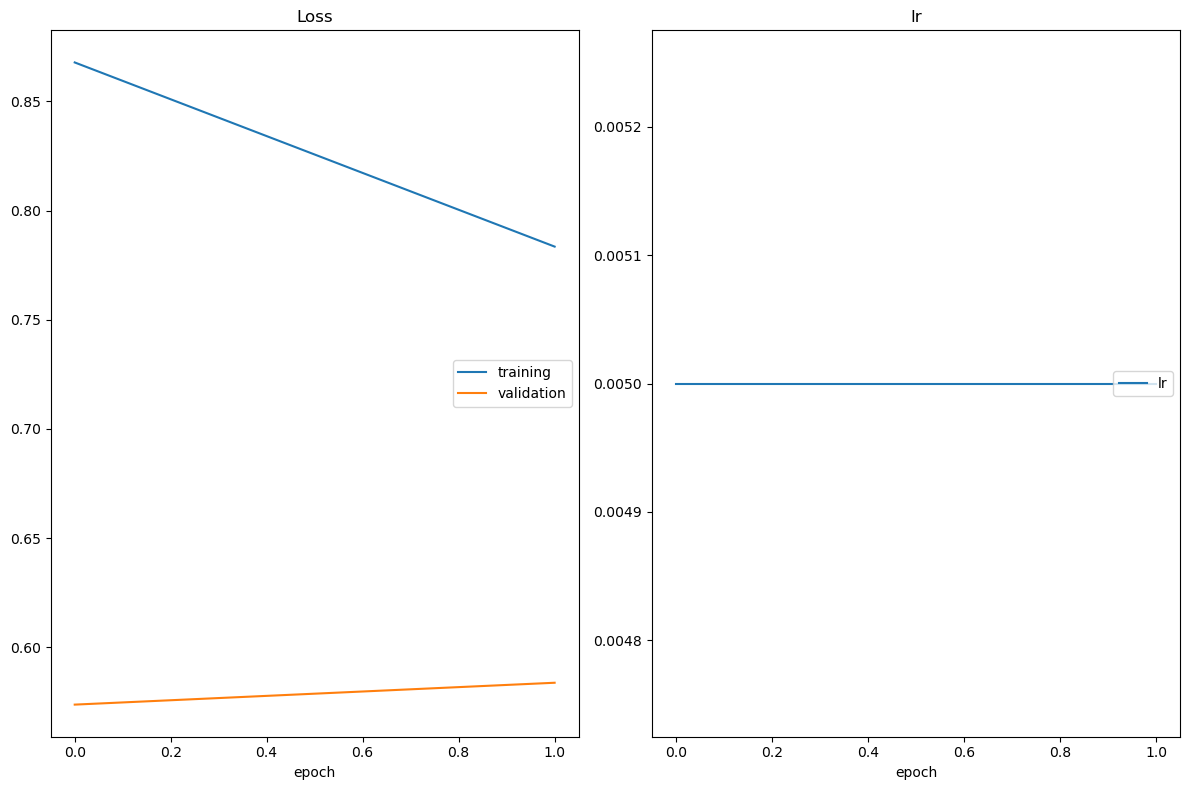

Loss
	training         	 (min:    0.783, max:    0.868, cur:    0.783)
	validation       	 (min:    0.574, max:    0.584, cur:    0.584)
lr
	lr               	 (min:    0.005, max:    0.005, cur:    0.005)


Training:  46%|█████████████▊                | 574/1250 [30:47<36:15,  3.22s/it]


KeyboardInterrupt: 

In [ ]:
n_epochs = 5

optimize(
    data_loaders,
    model,
    optimizer,
    loss,
    n_epochs,
    'cifar10_RN50_pretrained.pt',
    interactive_tracking=True
)

## Evaluate the Model
Now we can evaluate the model using the test set of data. We'll need a testing function similar to the validation function to accomplish this.

In [ ]:
def one_epoch_test(test_dataloader, model, loss):
    # monitor test loss and accuracy
    test_loss = 0.
    correct = 0.
    total = 0.

    # we do not need the gradients
    with torch.no_grad():

        # set the model to evaluation mode
        model.eval()  # -

        # if the GPU is available, move the model to the GPU
        if torch.cuda.is_available():
            model = model.cuda()

        # Loop over test dataset
        # We also accumulate predictions and targets so we can return them
        preds = []
        actuals = []

        for batch_idx, (data, target) in tqdm(
                enumerate(test_dataloader),
                desc='Testing',
                total=len(test_dataloader),
                leave=True,
                ncols=80
        ):
            # move data to GPU if available
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            # 1. forward pass: compute predicted outputs by passing inputs to the model
            logits = model(data)  # =

            # 2. calculate the loss
            loss_value = loss(logits, target).detach()  # =

            # 3. update average test loss
            test_loss = test_loss + ((1 / (batch_idx + 1)) * (loss_value.data.item() - test_loss))

            # 4. convert logits to predicted class
            # NOTE: the predicted class is the index of the max of the logits
            pred = logits.data.max(1, keepdim=True)[1]  # =

            # 5. compare predictions to true label
            correct += torch.sum(torch.squeeze(pred.eq(target.data.view_as(pred))).cpu())
            total += data.size(0)

            preds.extend(pred.data.cpu().numpy().squeeze())
            actuals.extend(target.data.view_as(pred).cpu().numpy().squeeze())

    print('Test Loss: {:.6f}\n'.format(test_loss))

    print('\nTest Accuracy: %2d%% (%2d/%2d)' % (100. * correct / total, correct, total))

    return test_loss, preds, actuals

#### Load the Best Model

In [ ]:
model.load_state_dict(torch.load('cifar10_RN50_pretrained.pt'))

<All keys matched successfully>

#### Test the Model
Now we want to run our test data through the network to make predictions. Not only will we compute the value of the loss function, but we'll also compute the accuracy of our trained model's predictions.

In [ ]:
test_loss, preds, actuals = one_epoch_test(data_loaders['test'], model, loss)

Testing: 100%|████████████████████████████████| 313/313 [07:40<00:00,  1.47s/it]

Test Loss: 0.585753


Test Accuracy: 80% (8002/10000)


#### Visualize the Accuracy
Let's plot a confusion matrix. We'll use the results from our test data above.

In [ ]:
def plot_confusion_matrix(pred, truth, classes):

    gt = pd.Series(truth, name='Ground Truth')
    predicted = pd.Series(pred, name='Predicted')

    confusion_matrix = pd.crosstab(gt, predicted)
    confusion_matrix.index = classes
    confusion_matrix.columns = classes

    fig, sub = plt.subplots()
    with sns.plotting_context("notebook"):

        ax = sns.heatmap(
            confusion_matrix,
            annot=True,
            fmt='d',
            ax=sub,
            linewidths=0.5,
            linecolor='lightgray',
            cbar=False
        )
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")

    return confusion_matrix

In [ ]:
cm = plot_confusion_matrix(preds, actuals, classes)

#### Visualize a Small Sample with Predictions

In [ ]:
%matplotlib inline

# helper function to un-normalize and display an image
def imshow(img, sub):
    img = img / 2 + 0.5  # unnormalize
    sub.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image
    sub.axis("off")

In [ ]:
# obtain one batch of test images
dataiter = iter(data_loaders['test'])

for i in range(2):
    images, labels = next(dataiter)
    images.numpy()

    # move model inputs to cuda, if GPU available
    if train_on_gpu:
        images = images.cuda()

    # get sample outputs
    output = model(images)
    # convert output probabilities to predicted class
    _, preds_tensor = torch.max(output, 1)
    preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())

    # plot the images in the batch, along with predicted and true labels
    fig, subs = plt.subplots(2, 10, figsize=(25, 4))
    for i, ax in enumerate(subs.flatten()):
        imshow(images[i].cpu().numpy(), ax)
        ax.set_title("{} ({})".format(classes[preds[i]], classes[labels[i]]),
                     color=("green" if preds[i]==labels[i].item() else "red"))
        ax.axis("off")